In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
def convolution(img, kernel):
    # First padding the image
    padded_img = np.pad(img, pad_width=1, mode='constant', constant_values=0)

    result = np.zeros(img.shape)
    
    f = padded_img.copy()
    w = kernel.copy()

    responses = list()
    
    # Applying convolution
    for x in range(1, padded_img.shape[0]-1):
        for y in range(1, padded_img.shape[1]-1):
            response = f[x-1][y-1]*w[0][0] + f[x-1][y]*w[0][1] + f[x-1][y+1]*w[0,2] + \
                       f[x][y-1]*w[1][0] + f[x][y]*w[1][1] + f[x][y]*w[1][2] + \
                       f[x+1][y-1]*w[2][0] + f[x+1][y]*w[2][1] + f[x+1][y+1]*w[2][2]
            responses.append(response)

    # Place the response in the resulting image
    c = 0
    for x in range(img.shape[0]):
        for y in range(img.shape[1]):
            result[x][y] = responses[c]
            c += 1

    return result

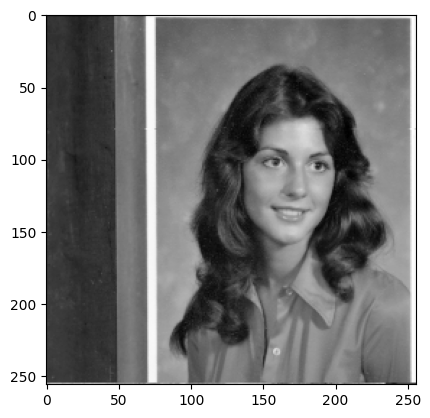

In [3]:
# Read the image
img = cv2.imread('misc/4.1.04.tiff', 0)
# Display the iamge
plt.imshow(img, cmap='gray')

Smoothed image


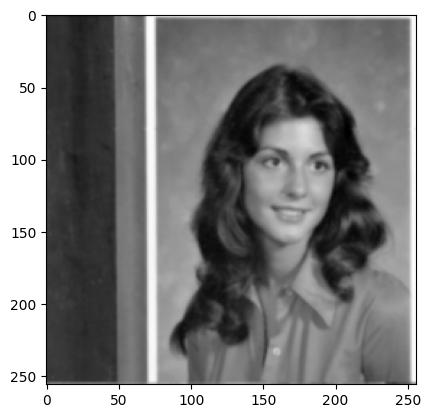

In [5]:
gaussian_img = cv2.GaussianBlur(img, (5, 5), 0.75)
print('Smoothed image')
plt.imshow(gaussian_img, cmap='gray')

In [26]:
laplacian_cn = np.array([[0,1,0],
                     [1,-4,1],
                     [0,1,0]])
log_img = convolution(gaussian_img, laplacian_cn)

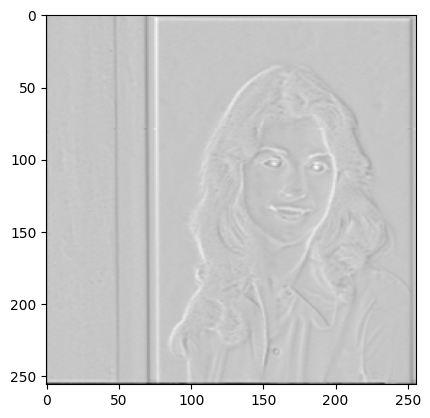

In [27]:
plt.imshow(log_img, cmap='gray')

In [20]:
# Zero Crossing

def zero_crossing(log_img, t_p):
    max_pixel = np.max(log_img)
    threshold = t_p * max_pixel
    padded_img = np.pad(log_img, pad_width=1, mode='constant', constant_values=0)
    result = np.zeros(log_img.shape)
    f = padded_img
    
    for x in range(1, result.shape[0]-1):
        for y in range(1, result.shape[1]-1):
            l_d = abs(f[x-1][y-1] - f[x+1][y+1])
            r_d = abs(f[x-1][y+1] - f[x+1][y-1])
            t_b = abs(f[x-1][y] - f[x+1][y])
            l_r = abs(f[x][y+1] - f[x][y-1])

            if(l_d>threshold or r_d>threshold or t_b>threshold or l_r>threshold):
                result[x-1][y-1] = 1
            else:
                result[x-1][y-1] = 0

    return result

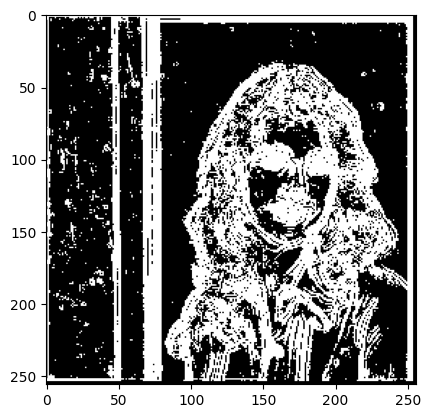

In [30]:
result = zero_crossing(log_img, 0.1)
plt.imshow(result, cmap='gray')